This notebook explores the OECD datasets that will be used as training data for the models: CPI index, RGDP growth, unemployment rate. The data will be pre-processed by putting it into pandas dataframes with long-format panel data

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from utils.tests import check_stationarity
from statsmodels.graphics.tsaplots import plot_pacf
import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.simplefilter('ignore', InterpolationWarning)

In [2]:
cpi_index = pd.read_csv('..\\data\\raw_data\\CPI_index.csv')
rgdp = pd.read_csv('..\\data\\raw_data\\RGDP_growth_rate.csv')
unemp = pd.read_csv('..\\data\\raw_data\\unemployment_rate.csv')

In [3]:
cpi_index.columns

Index(['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'ACTION', 'REF_AREA',
       'Reference area', 'FREQ', 'Frequency of observation', 'METHODOLOGY',
       'Methodology', 'MEASURE', 'Measure', 'UNIT_MEASURE', 'Unit of measure',
       'EXPENDITURE', 'Expenditure', 'ADJUSTMENT', 'Adjustment',
       'TRANSFORMATION', 'Transformation', 'TIME_PERIOD', 'Time period',
       'OBS_VALUE', 'Observation value', 'OBS_STATUS', 'Observation status',
       'UNIT_MULT', 'Unit multiplier', 'BASE_PER', 'Base period', 'DURABILITY',
       'Durability', 'DECIMALS', 'Decimals'],
      dtype='str')

All the columns in the original dataframe are not needed, as OECD includes lots of additional data for every sample, which is predominantly not required. Only the country, time stamp, and the value itself are needed

In [4]:
cpi_index = cpi_index[['Reference area', 'TIME_PERIOD', 'OBS_VALUE']]
rgdp = rgdp[['Reference area', 'TIME_PERIOD', 'OBS_VALUE']]
unemp = unemp[['Reference area', 'TIME_PERIOD', 'OBS_VALUE']]
cpi_index.head()

,Reference area,TIME_PERIOD,OBS_VALUE
0,United States,2026-Q2,140.931500
1,Indonesia,2026-Q2,137.166300
2,United Kingdom,2026-Q2,142.100000
3,South Africa,1980-Q1,4.698460
4,South Africa,1980-Q2,4.852004


Due to unconsistent availability of data, for training and in-sample evaluation, only the values from 1993 to 2019 (incl) will be used for the following countries: Australia, Austria, Belgium, Canada, Denmark, Finland, France, Germany, Ireland, Italy,
Japan, Korea, Luxembourg, Mexico, Netherlands, New Zealand, Norway, Portugal, Spain, Sweden, United Kingdom, United States

In [5]:
cpi_index = cpi_index.loc[(cpi_index['TIME_PERIOD'].str[:4].astype(int) > 1992) & (cpi_index['TIME_PERIOD'].str[:4].astype(int) < 2020), :]
rgdp = rgdp.loc[(rgdp['TIME_PERIOD'].str[:4].astype(int) > 1992) & (rgdp['TIME_PERIOD'].str[:4].astype(int) < 2020), :]
unemp = unemp.loc[(unemp['TIME_PERIOD'].str[:4].astype(int) > 1992) & (unemp['TIME_PERIOD'].str[:4].astype(int) < 2020), :]

In [6]:
list_of_countries = ['Australia', 'Austria', 'Belgium', 'Canada', 'Denmark', 'Finland', 'France', 'Germany', 'Ireland',
                     'Italy', 'Japan', 'Korea', 'Luxembourg', 'Mexico', 'Netherlands', 'New Zealand', 'Norway', 'Portugal',
                     'Spain', 'Sweden', 'United Kingdom', 'United States']
cpi_index = cpi_index.loc[cpi_index['Reference area'].isin(list_of_countries), :]
rgdp = rgdp.loc[rgdp['Reference area'].isin(list_of_countries), :]
unemp = unemp.loc[unemp['Reference area'].isin(list_of_countries), :]

In [7]:
# sorting the values
cpi_index = cpi_index.sort_values(by = 'TIME_PERIOD')
rgdp = rgdp.sort_values(by = 'TIME_PERIOD')
unemp = unemp.sort_values(by = 'TIME_PERIOD')
cpi_index.loc[cpi_index['Reference area'] == 'Australia']

,Reference area,TIME_PERIOD,OBS_VALUE
2281,Australia,1993-Q1,56.28047
2282,Australia,1993-Q2,56.46622
2283,Australia,1993-Q3,56.74483
2284,Australia,1993-Q4,56.83771
2285,Australia,1994-Q1,57.11632
...,...,...,...
2384,Australia,2018-Q4,105.96700
2385,Australia,2019-Q1,105.96700
2386,Australia,2019-Q2,106.61710
2387,Australia,2019-Q3,107.17440


RGDP is already in the form of percentage difference, unemployment is a percentage, but CPI is just a raw index, therefore I will compute the percentage growth for it 

In [8]:
for index, country in enumerate(list_of_countries):
    if index == 0:
        curr_series = cpi_index.loc[cpi_index['Reference area'] == country]
        curr_series['OBS_VALUE'] = curr_series['OBS_VALUE'].pct_change(periods = 4) * 100
        cpi_yoy = curr_series
    else:
        curr_series = cpi_index.loc[cpi_index['Reference area'] == country]
        curr_series['OBS_VALUE'] = curr_series['OBS_VALUE'].pct_change(periods = 4) * 100
        cpi_yoy = pd.concat([cpi_yoy, curr_series])
cpi_yoy

,Reference area,TIME_PERIOD,OBS_VALUE
2281,Australia,1993-Q1,NaN
2282,Australia,1993-Q2,NaN
2283,Australia,1993-Q3,NaN
2284,Australia,1993-Q4,NaN
2285,Australia,1994-Q1,1.485151
...,...,...,...
2016,United States,2018-Q4,2.203150
2017,United States,2019-Q1,1.644898
2018,United States,2019-Q2,1.811376
2019,United States,2019-Q3,1.757537


The data points for the first year cannot be computed for CPI, so only the data after 1994 (incl.) will be used

In [9]:
cpi_yoy = cpi_yoy[~cpi_yoy['TIME_PERIOD'].isin(['1993-Q1', '1993-Q2', '1993-Q3', '1993-Q4'])].sort_values(by = ['Reference area', 'TIME_PERIOD'])
rgdp = rgdp[~rgdp['TIME_PERIOD'].isin(['1993-Q1', '1993-Q2', '1993-Q3', '1993-Q4'])].sort_values(by = ['Reference area', 'TIME_PERIOD'])
unemp = unemp[~unemp['TIME_PERIOD'].isin(['1993-Q1', '1993-Q2', '1993-Q3', '1993-Q4'])].sort_values(by = ['Reference area', 'TIME_PERIOD'])
# resetting the index 
cpi_yoy = cpi_yoy.reset_index(drop = True)
rgdp = rgdp.reset_index(drop = True)
unemp = unemp.reset_index(drop = True)

In [10]:
# checking whether any data points are missing from currently selected data
print(cpi_yoy['OBS_VALUE'].isna().sum())
print(rgdp['OBS_VALUE'].isna().sum())
print(unemp['OBS_VALUE'].isna().sum())

0
0
0


I will now examine the time series plots of the metrics for several countries

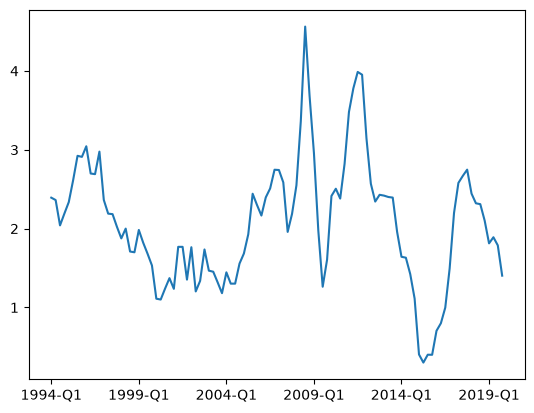

In [11]:
plt.plot(cpi_yoy.loc[cpi_yoy['Reference area'] == 'United Kingdom', 'TIME_PERIOD'], \
         cpi_yoy.loc[cpi_yoy['Reference area'] == 'United Kingdom', 'OBS_VALUE'], label = 'CPI inflation')
plt.xticks(cpi_yoy.loc[cpi_yoy['Reference area'] == 'United Kingdom', 'TIME_PERIOD'][::20])
plt.show()

The CPI inflation in the UK saw a relatively stable outlook before the 2008 financial crisis, when it first rose to the highest in the given time period, then dipped, and continued to exhibit a much more volatile behaviour 

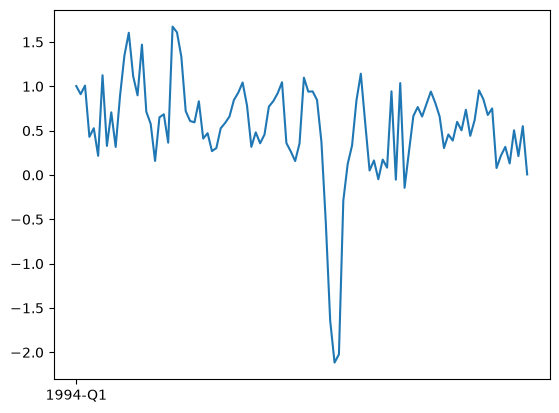

In [12]:
plt.plot(rgdp.loc[rgdp['Reference area'] == 'United Kingdom', 'TIME_PERIOD'], \
         rgdp.loc[rgdp['Reference area'] == 'United Kingdom', 'OBS_VALUE'], label = 'RGDP Growth')
plt.xticks(rgdp.loc[rgdp['Reference area'] == 'United Kingdom', 'TIME_PERIOD'][::350])
plt.show()

RGDP growth in France was mostly moderately positive up to 2008, dipping into negatives two times in the early 2000s, and then saw a fall by 2% in 2009 Q1, exhibiting a a more volatile outlook after that, but still averaging at around 0.25%

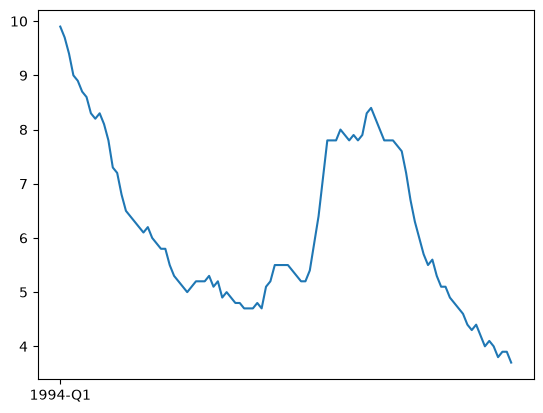

In [13]:
plt.plot(unemp.loc[unemp['Reference area'] == 'United Kingdom', 'TIME_PERIOD'], \
         unemp.loc[unemp['Reference area'] == 'United Kingdom', 'OBS_VALUE'], label = 'Unemployment rate')
plt.xticks(unemp.loc[unemp['Reference area'] == 'United Kingdom', 'TIME_PERIOD'][::350])
plt.show()

I will now run ADF and KPSS tests on each of the variables per-country, to determine the number of countries for which a variable is non-stationary for each variable

In [14]:
print('CPI')
check_stationarity(cpi_yoy, list_of_countries)
print('\nRGDP')
check_stationarity(rgdp, list_of_countries)
print('\nUnemployment')
check_stationarity(unemp, list_of_countries)

CPI
Denmark is non-stationary with p-value_adfuller of 0.4762378174051911 and p-value_kpss 0.01
Ireland is non-stationary with p-value_adfuller of 0.06694930103323221 and p-value_kpss 0.022514672306794624
Italy is non-stationary with p-value_adfuller of 0.5538463965275664 and p-value_kpss 0.01
Korea is non-stationary with p-value_adfuller of 0.6398842587114676 and p-value_kpss 0.01
Portugal is non-stationary with p-value_adfuller of 0.09390566671524714 and p-value_kpss 0.01
Spain is non-stationary with p-value_adfuller of 0.7271526914572047 and p-value_kpss 0.01

RGDP

Unemployment
Australia is non-stationary with p-value_adfuller of 0.07521811988959003 and p-value_kpss 0.01
Austria is non-stationary with p-value_adfuller of 0.21159728680986006 and p-value_kpss 0.01
Belgium is non-stationary with p-value_adfuller of 0.17038020290909583 and p-value_kpss 0.017283368010055297
Canada is non-stationary with p-value_adfuller of 0.27706782006273256 and p-value_kpss 0.01
Germany is non-station

While RGDP time series for all countries are stationary, CPI year-on-year inflation is non-stationary for 6 countries, and unemployment rate for 9, so those variables need to be differenced before being used as inputs/targets for neural nets

In [15]:
# saving the processed dataframes
cpi_yoy.to_csv('..\\data\\structured_data\\CPI_growth_yoy_dataframe.csv')
rgdp.to_csv('..\\data\\structured_data\\RGDP_growth_dataframe.csv')
unemp.to_csv('..\\data\\structured_data\\unemployment_rate_dataframe.csv')